# Dry Bean Classification using Machine Learning

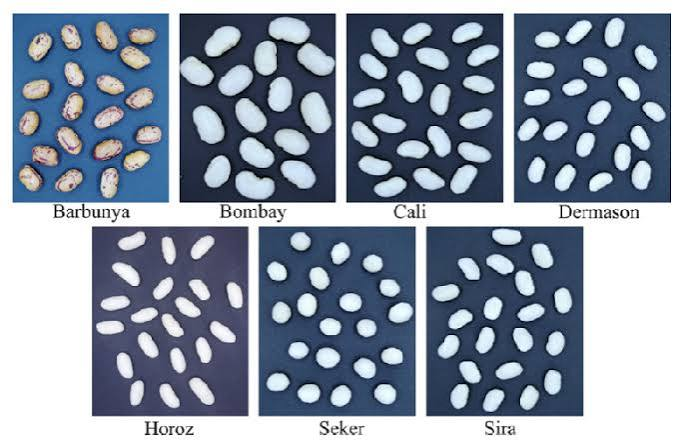

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("dry_bean_dataset.csv")

In [4]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [5]:
df.tail()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653247,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON
13610,42159,772.237,295.142741,182.204716,1.619841,0.786693,42600,231.686223,0.788962,0.989648,0.888380,0.784997,0.007001,0.001640,0.616221,0.998180,DERMASON


In [6]:
df.shape

(13611, 17)

In [7]:
df.columns

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4', 'Class'],
      dtype='str')

| No. | Feature | Simple Meaning | What It Tells Us |
|---:|---|---|---|
| 1 | **Area** | Total area occupied by the bean in the image | Overall size of the bean |
| 2 | **Perimeter** | Length around the outer boundary of the bean | Boundary/outline size |
| 3 | **MajorAxisLength** | Length of the bean along its longest direction | How long the bean is |
| 4 | **MinorAxisLength** | Length across the bean's shortest direction | How wide the bean is |
| 5 | **AspectRation** | Ratio of major axis to minor axis | How elongated the bean is |
| 6 | **Eccentricity** | Measures how different the bean is from a circle | Round vs. elongated shape |
| 7 | **ConvexArea** | Area of the smallest convex shape covering the bean | Irregularity of the bean boundary |
| 8 | **EquivDiameter** | Diameter of a circle having the same area as the bean | Equivalent size in circular form |
| 9 | **Extent** | Ratio of bean area to its bounding-box area | How much of the surrounding box the bean fills |
| 10 | **Solidity** | Ratio of bean area to convex area | How solid/regular the bean shape is |
| 11 | **roundness** | Measures how close the bean is to a circle | Circularity of the bean |
| 12 | **Compactness** | Measures how compact the bean is based on its area and perimeter | Overall compactness |
| 13 | **ShapeFactor1** | Mathematical ratio derived from area, perimeter and axis dimensions | Fine shape characteristics |
| 14 | **ShapeFactor2** | Mathematical shape descriptor derived from bean geometry | Shape differences between bean types |
| 15 | **ShapeFactor3** | Another mathematical descriptor of bean shape | Shape/compactness characteristics |
| 16 | **ShapeFactor4** | Mathematical descriptor related to the bean's geometric shape | Fine boundary/shape differences |
| 17 | **Class** | Name/type of the bean | **Target variable for KNN classification** |

In [8]:
df.duplicated().sum()

np.int64(68)

In [9]:
df = df.drop_duplicates()

In [10]:
df.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 13543 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13543 non-null  int64  
 1   Perimeter        13543 non-null  float64
 2   MajorAxisLength  13543 non-null  float64
 3   MinorAxisLength  13543 non-null  float64
 4   AspectRation     13543 non-null  float64
 5   Eccentricity     13543 non-null  float64
 6   ConvexArea       13543 non-null  int64  
 7   EquivDiameter    13543 non-null  float64
 8   Extent           13543 non-null  float64
 9   Solidity         13543 non-null  float64
 10  roundness        13543 non-null  float64
 11  Compactness      13543 non-null  float64
 12  ShapeFactor1     13543 non-null  float64
 13  ShapeFactor2     13543 non-null  float64
 14  ShapeFactor3     13543 non-null  float64
 15  ShapeFactor4     13543 non-null  float64
 16  Class            13543 non-null  str    
dtypes: float64(14), int64(2), st

In [12]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000
mean,53048.460385,854.993406,319.895602,202.365321,1.581075,0.750315,53767.986709,253.034094,0.749829,0.987152,0.873671,0.800352,0.006561,0.001719,0.644341,0.995078
std,29392.438324,214.722684,85.809260,45.051632,0.245245,0.091858,29844.248525,59.307709,0.048939,0.004650,0.059393,0.061464,0.001130,0.000595,0.098653,0.004347
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36282.500000,703.230000,253.086806,175.886357,1.430662,0.715144,36673.000000,214.933277,0.718735,0.985678,0.833410,0.763228,0.005893,0.001158,0.582517,0.993720
50%,44580.000000,793.896000,296.404589,192.491117,1.549860,0.763997,45122.000000,238.245711,0.759903,0.988288,0.883490,0.801514,0.006643,0.001700,0.642424,0.996393
75%,61382.000000,977.146500,376.312489,217.245403,1.703916,0.809671,62360.000000,279.560351,0.786849,0.990019,0.917031,0.834470,0.007270,0.002173,0.696341,0.997891
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [13]:
df.nunique()

Area               12011
Perimeter          13351
MajorAxisLength    13543
MinorAxisLength    13543
AspectRation       13543
Eccentricity       13543
ConvexArea         12066
EquivDiameter      12011
Extent             13535
Solidity           13522
roundness          13540
Compactness        13543
ShapeFactor1       13521
ShapeFactor2       13506
ShapeFactor3       13543
ShapeFactor4       13532
Class                  7
dtype: int64

In [14]:
object_columns = df.select_dtypes(include=['str', 'bool']).columns
print("Object type columns:")
print(object_columns)

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumerical type columns:")
print(numerical_columns)

Object type columns:
Index(['Class'], dtype='str')

Numerical type columns:
Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4'],
      dtype='str')


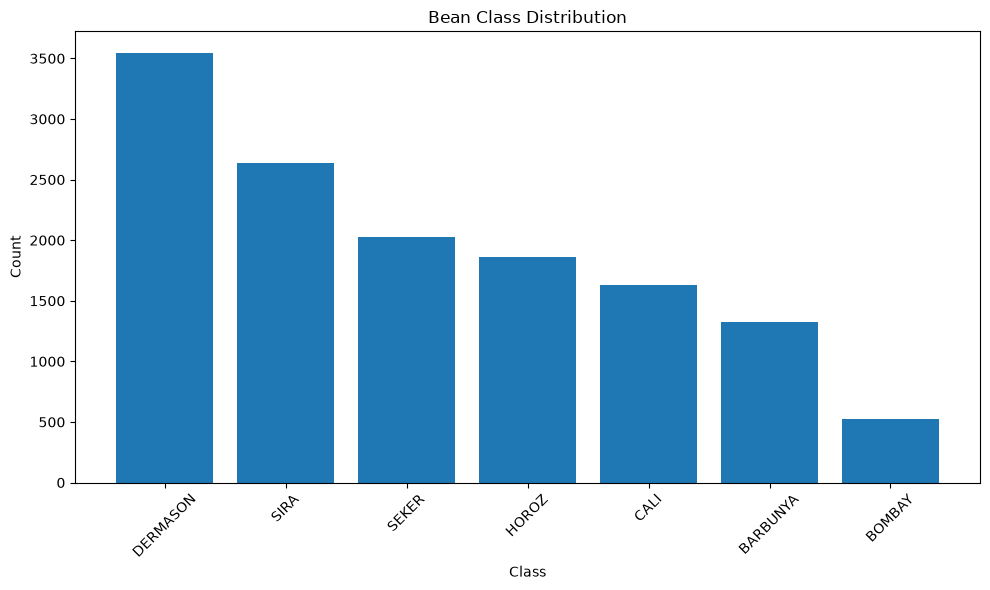

In [15]:
plt.figure(figsize=(10,6))
class_counts = df['Class'].value_counts()
plt.bar(class_counts.index, class_counts.values)
plt.title('Bean Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

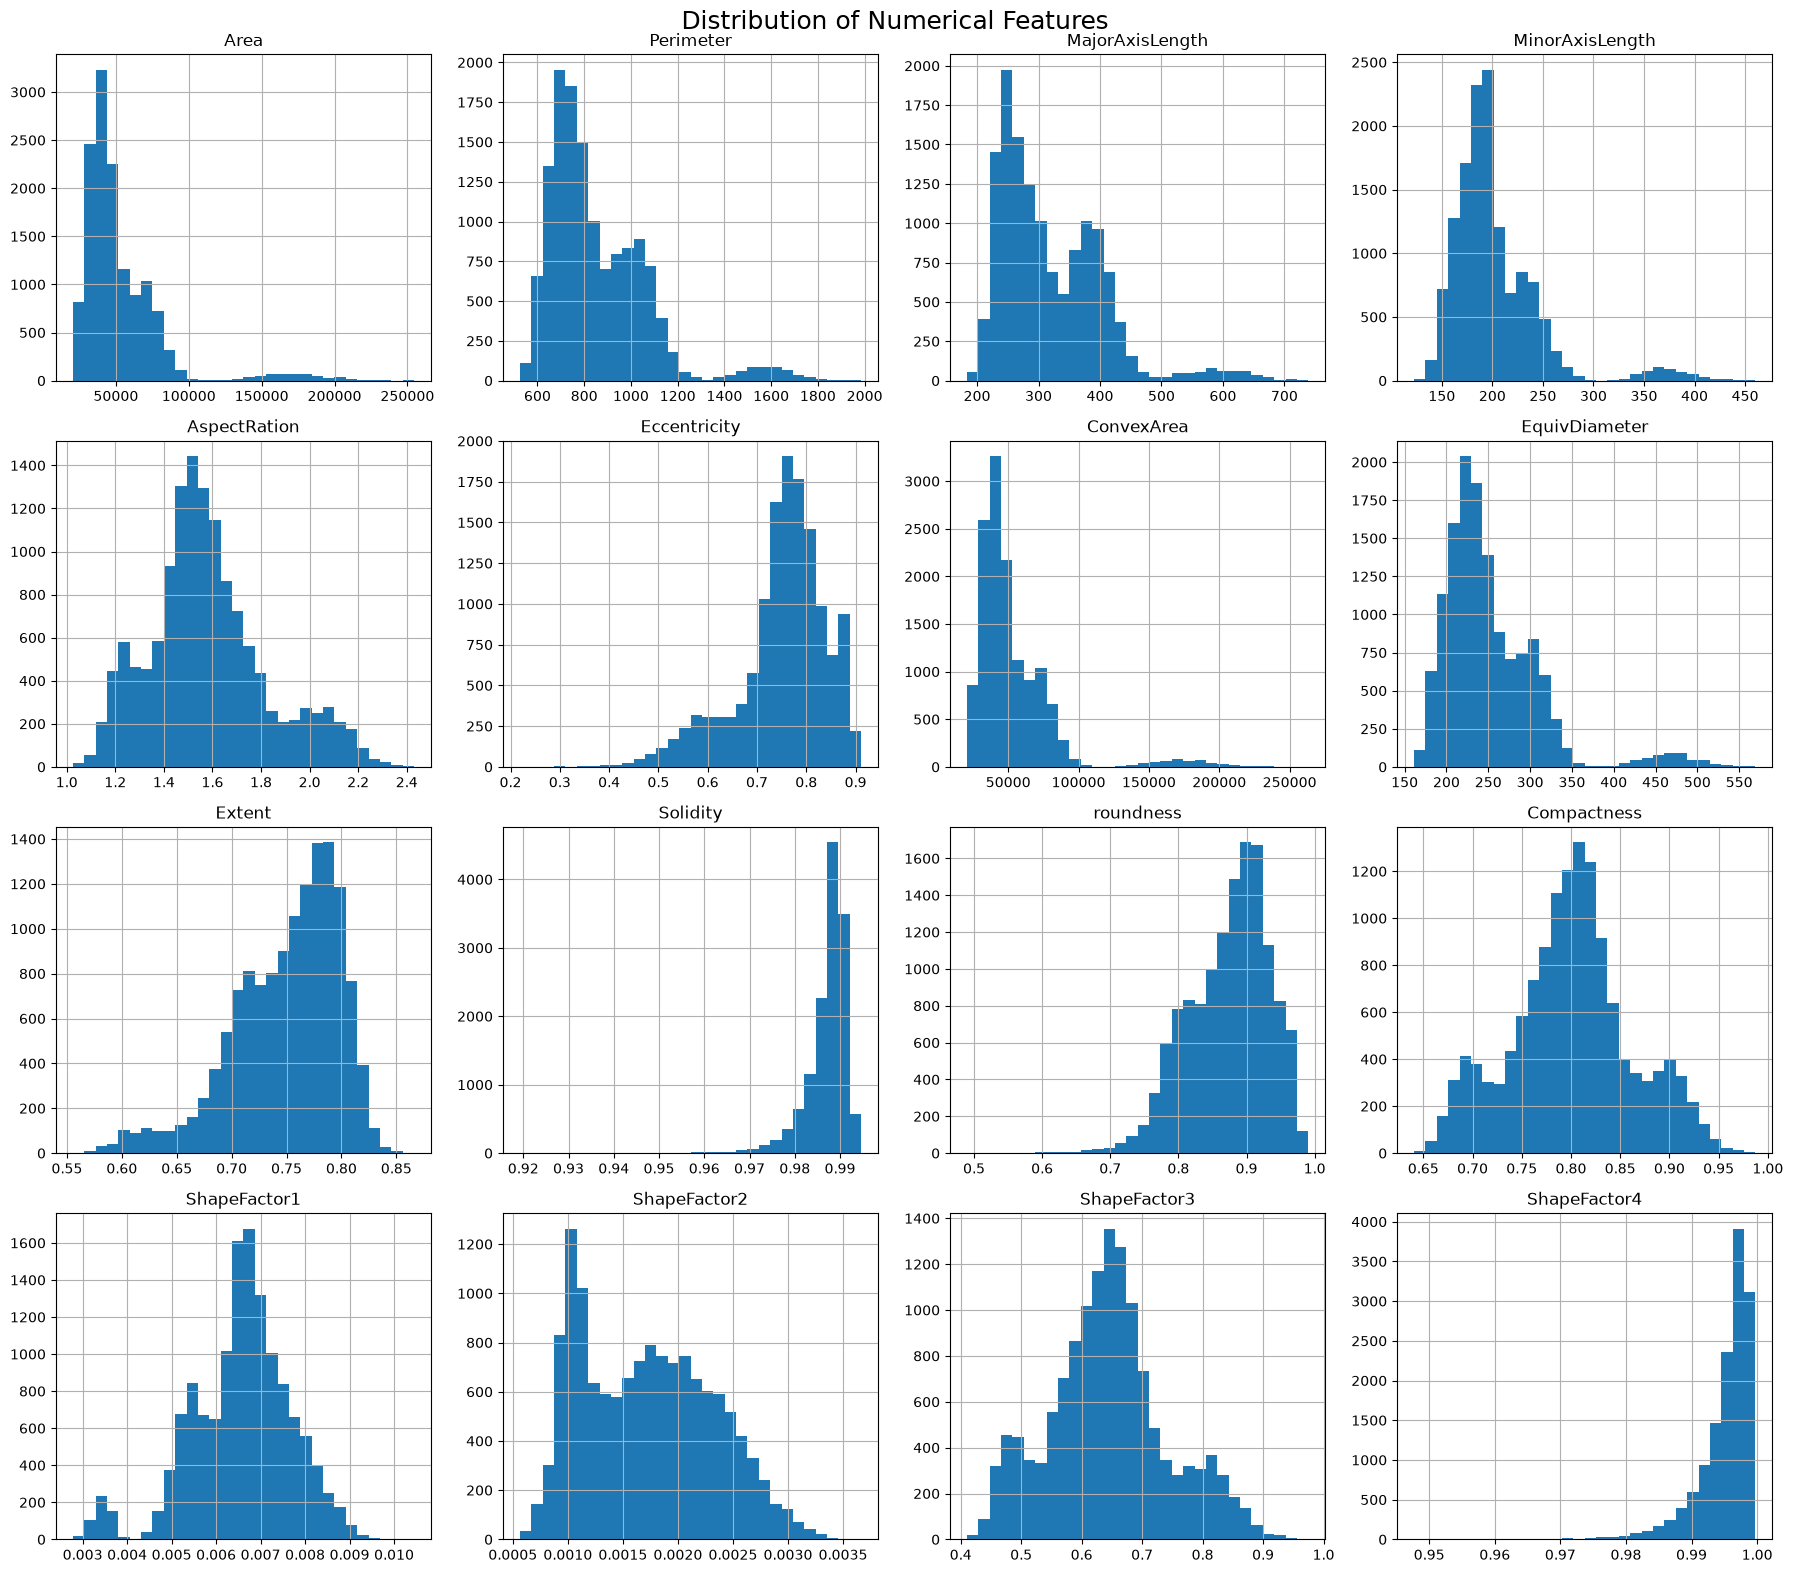

In [16]:
df.hist(figsize=(18,16), bins=30)
plt.suptitle('Distribution of Numerical Features', fontsize=18)
plt.tight_layout()
plt.show()

In [17]:
numerical_cols = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4']

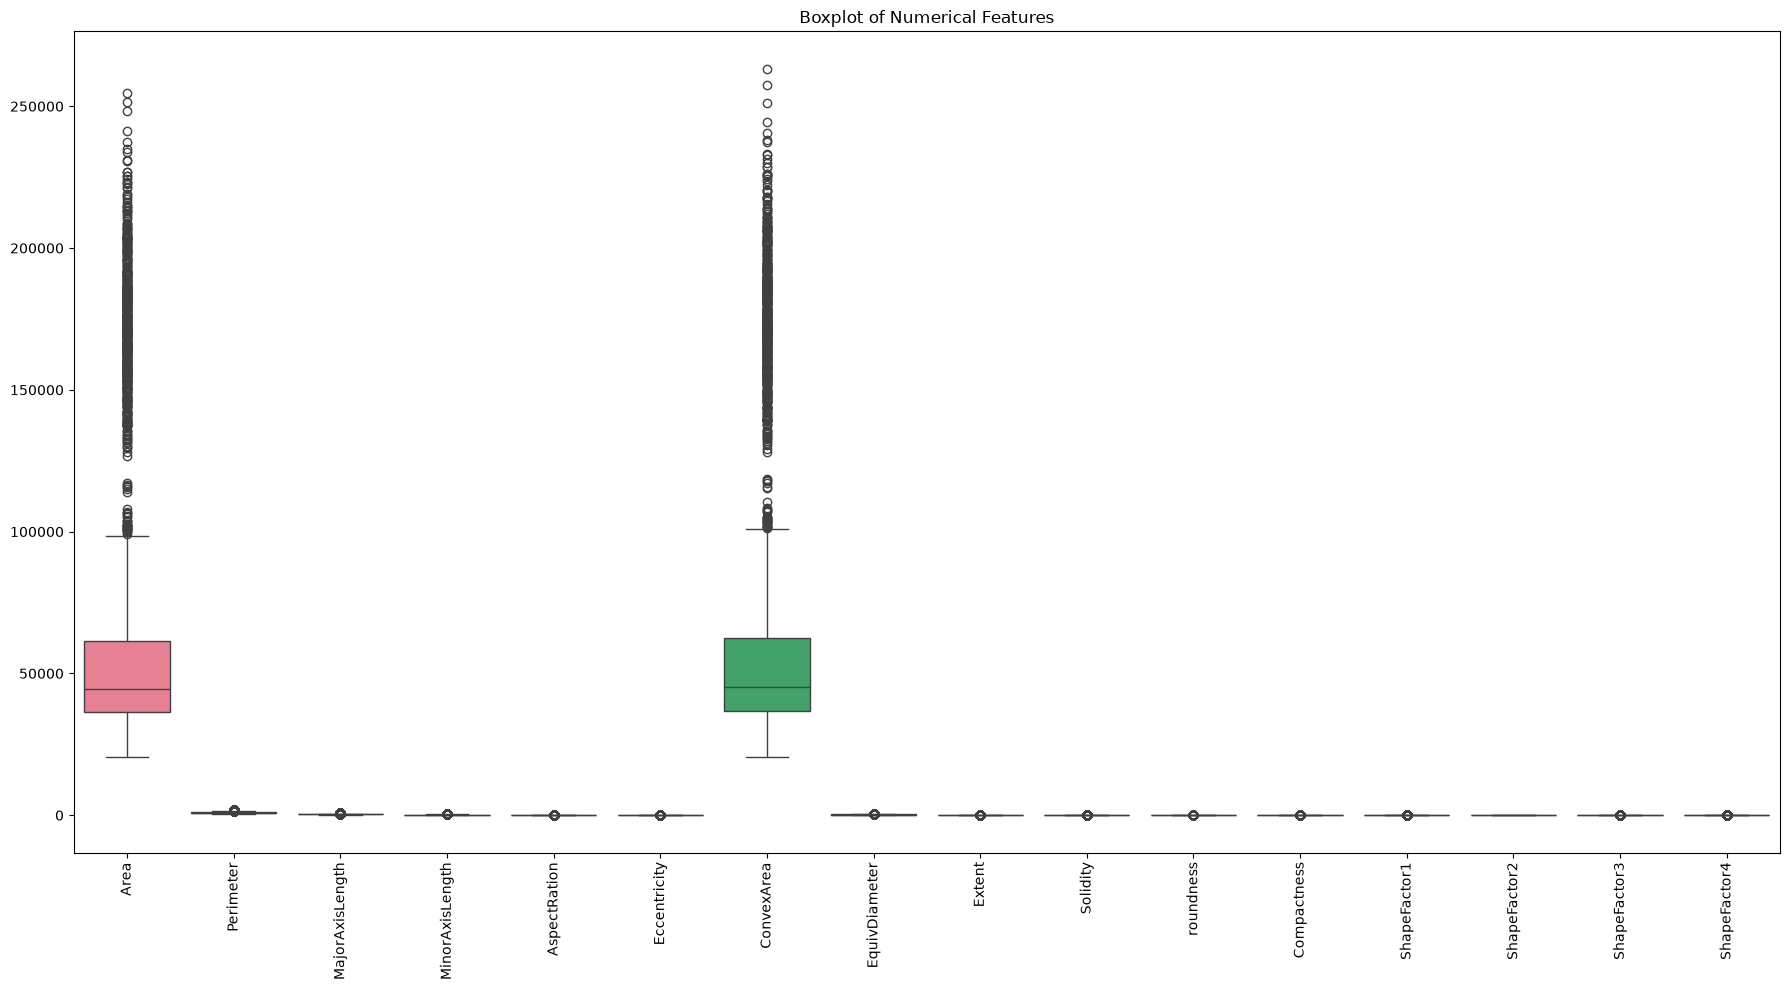

In [18]:
plt.figure(figsize=(18,10))
sns.boxplot(data=df[numerical_cols])
plt.title('Boxplot of Numerical Features')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

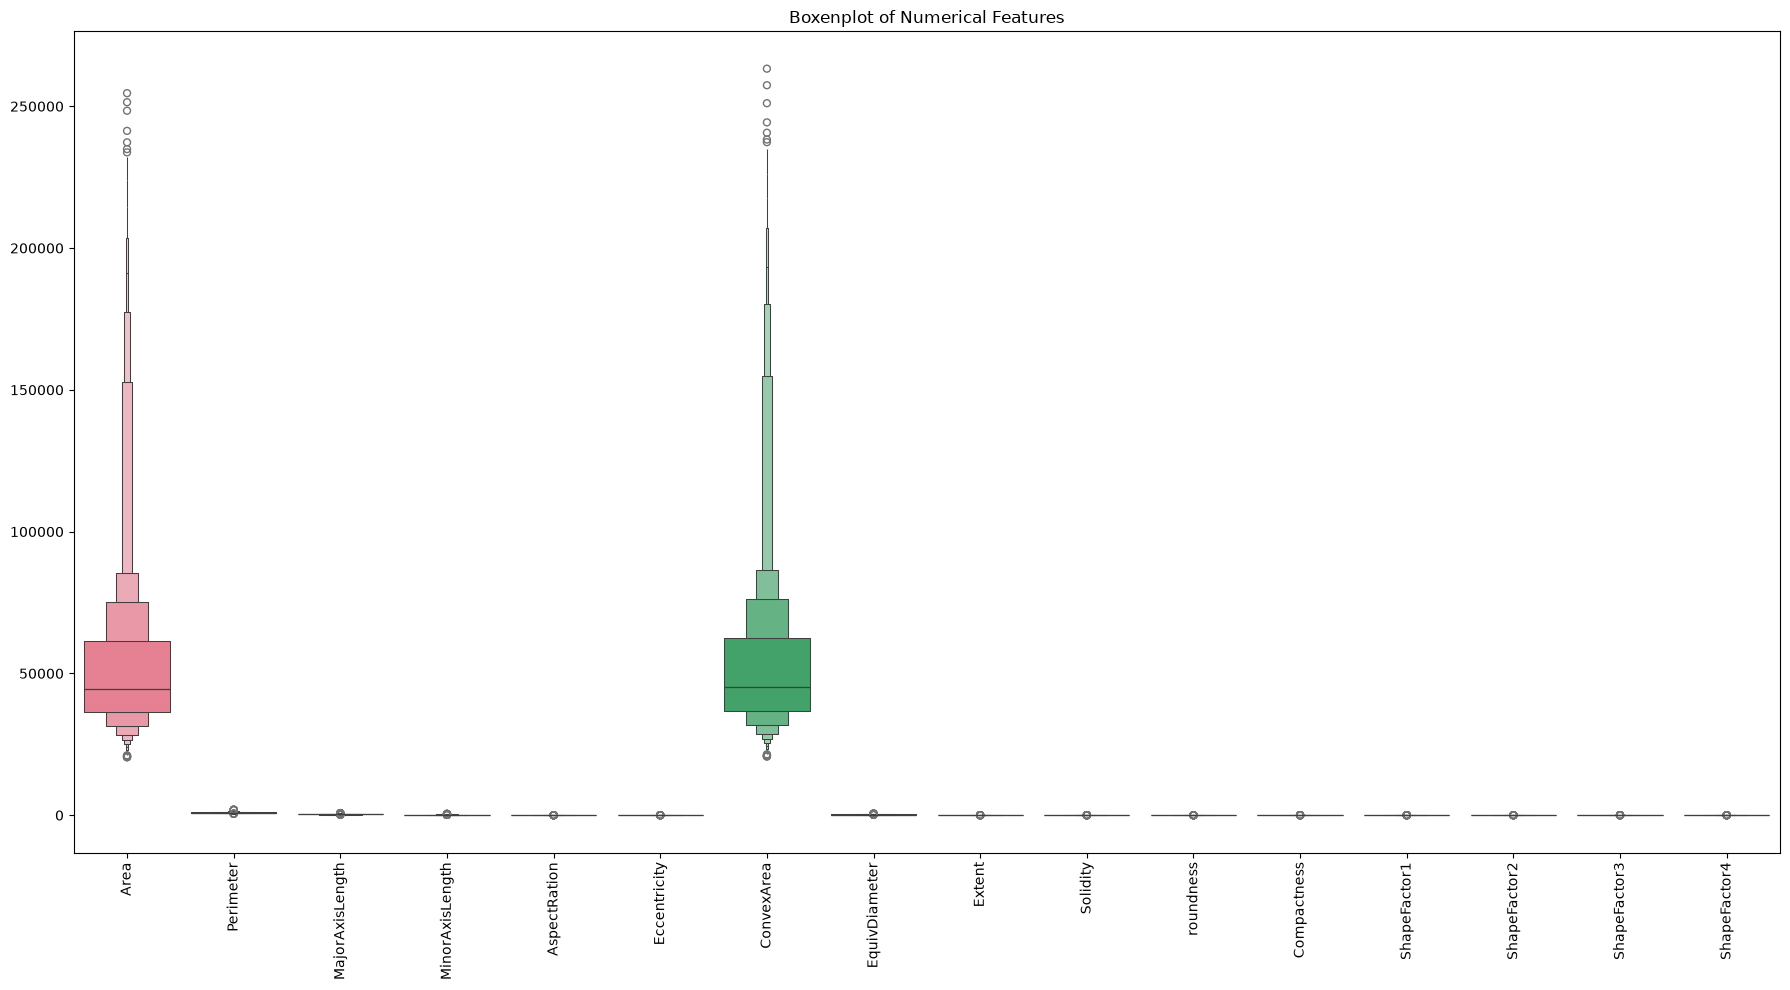

In [21]:
plt.figure(figsize=(18,10))
sns.boxenplot(data=df[numerical_cols])
plt.title('Boxenplot of Numerical Features')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

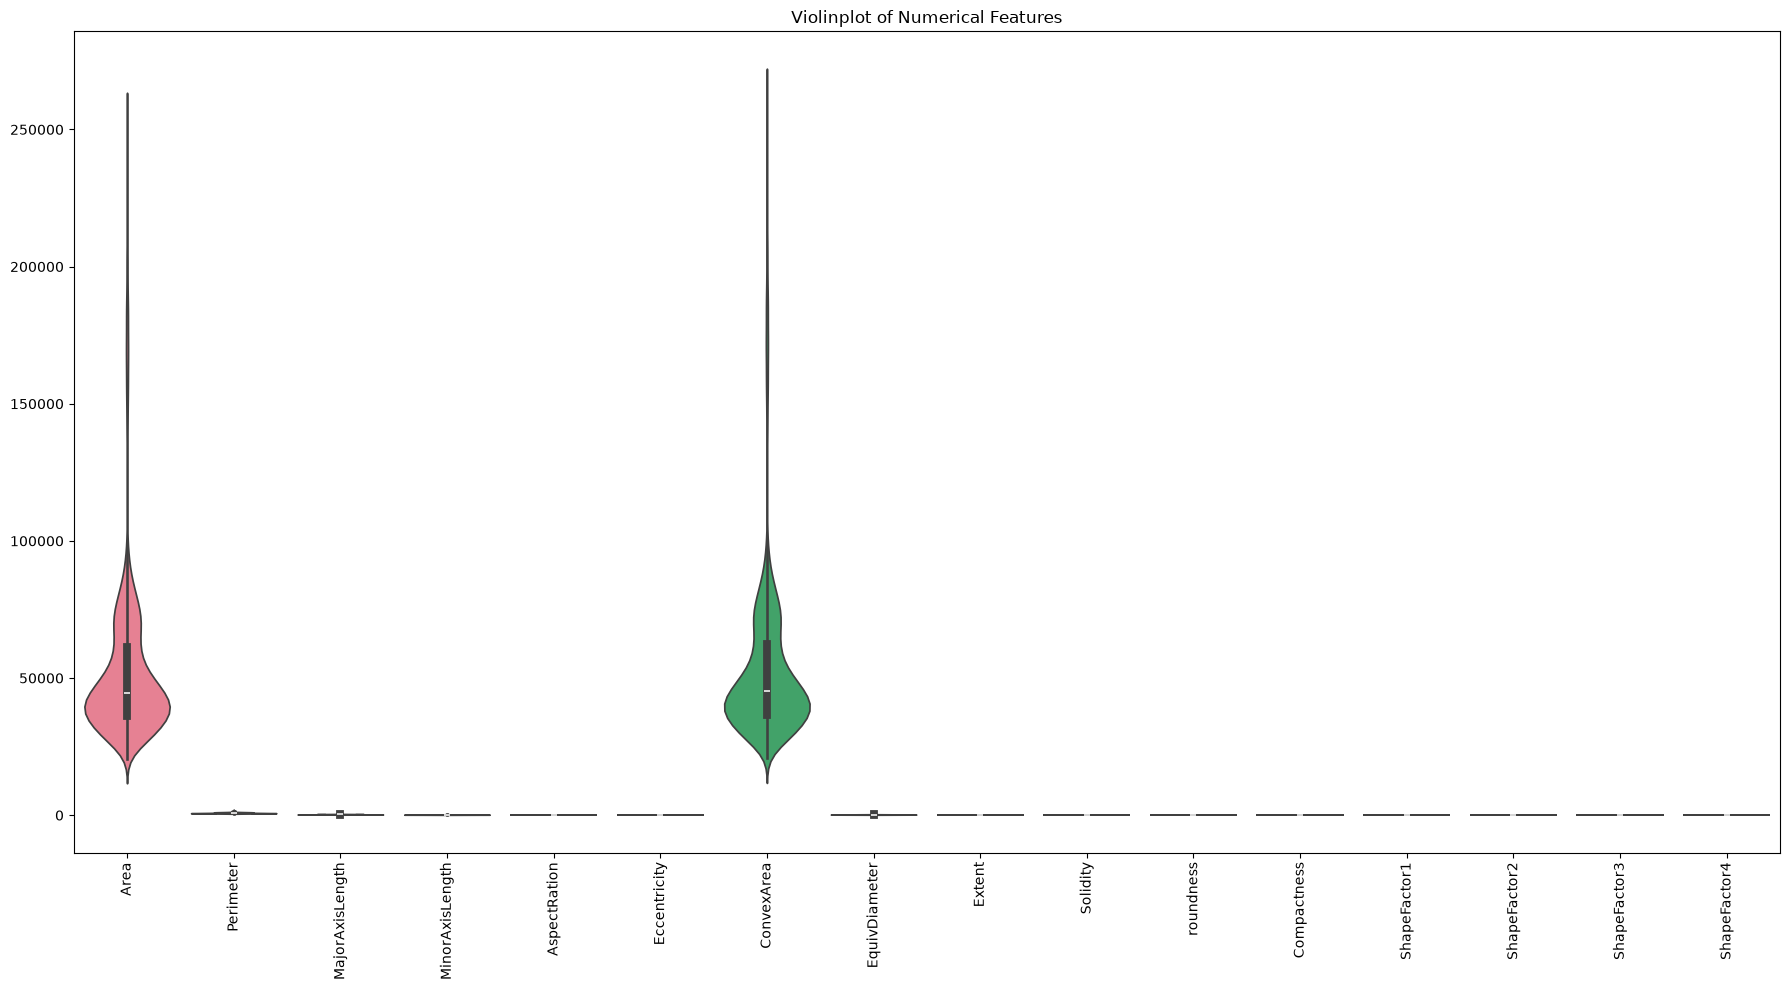

In [22]:
plt.figure(figsize=(18,10))
sns.violinplot(data=df[numerical_cols])
plt.title('Violinplot of Numerical Features')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

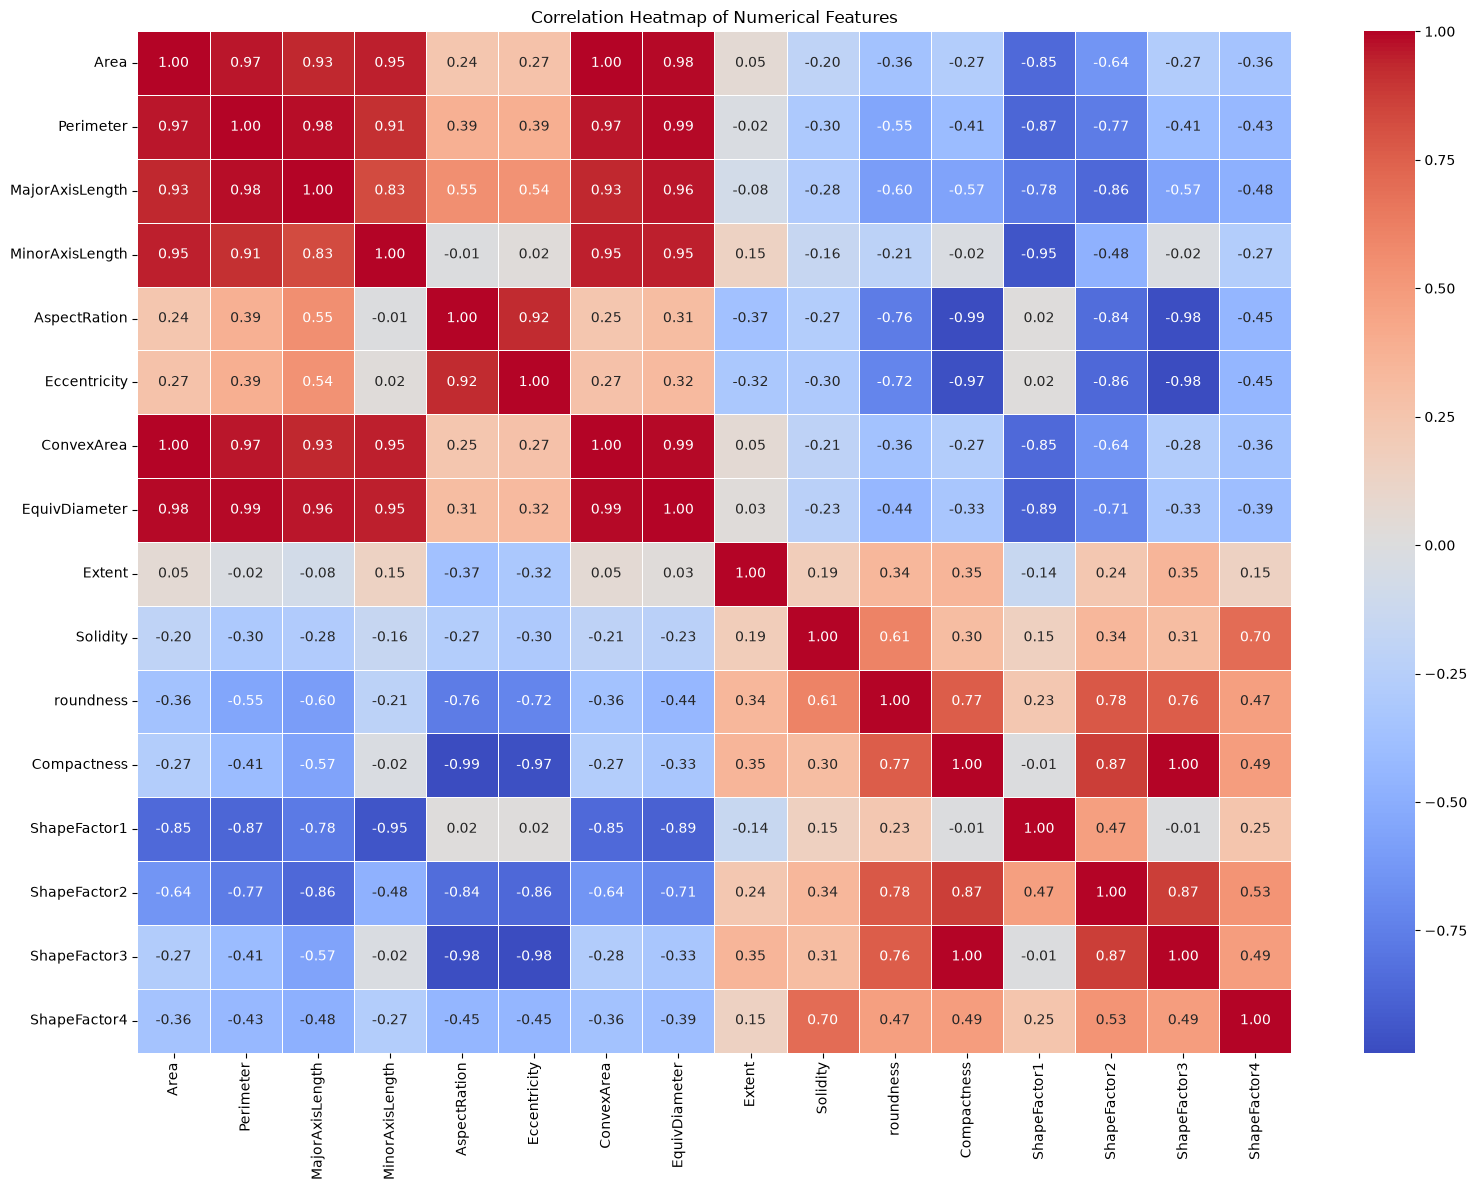

In [23]:
plt.figure(figsize=(16,12))
corr = df[numerical_cols].corr()
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

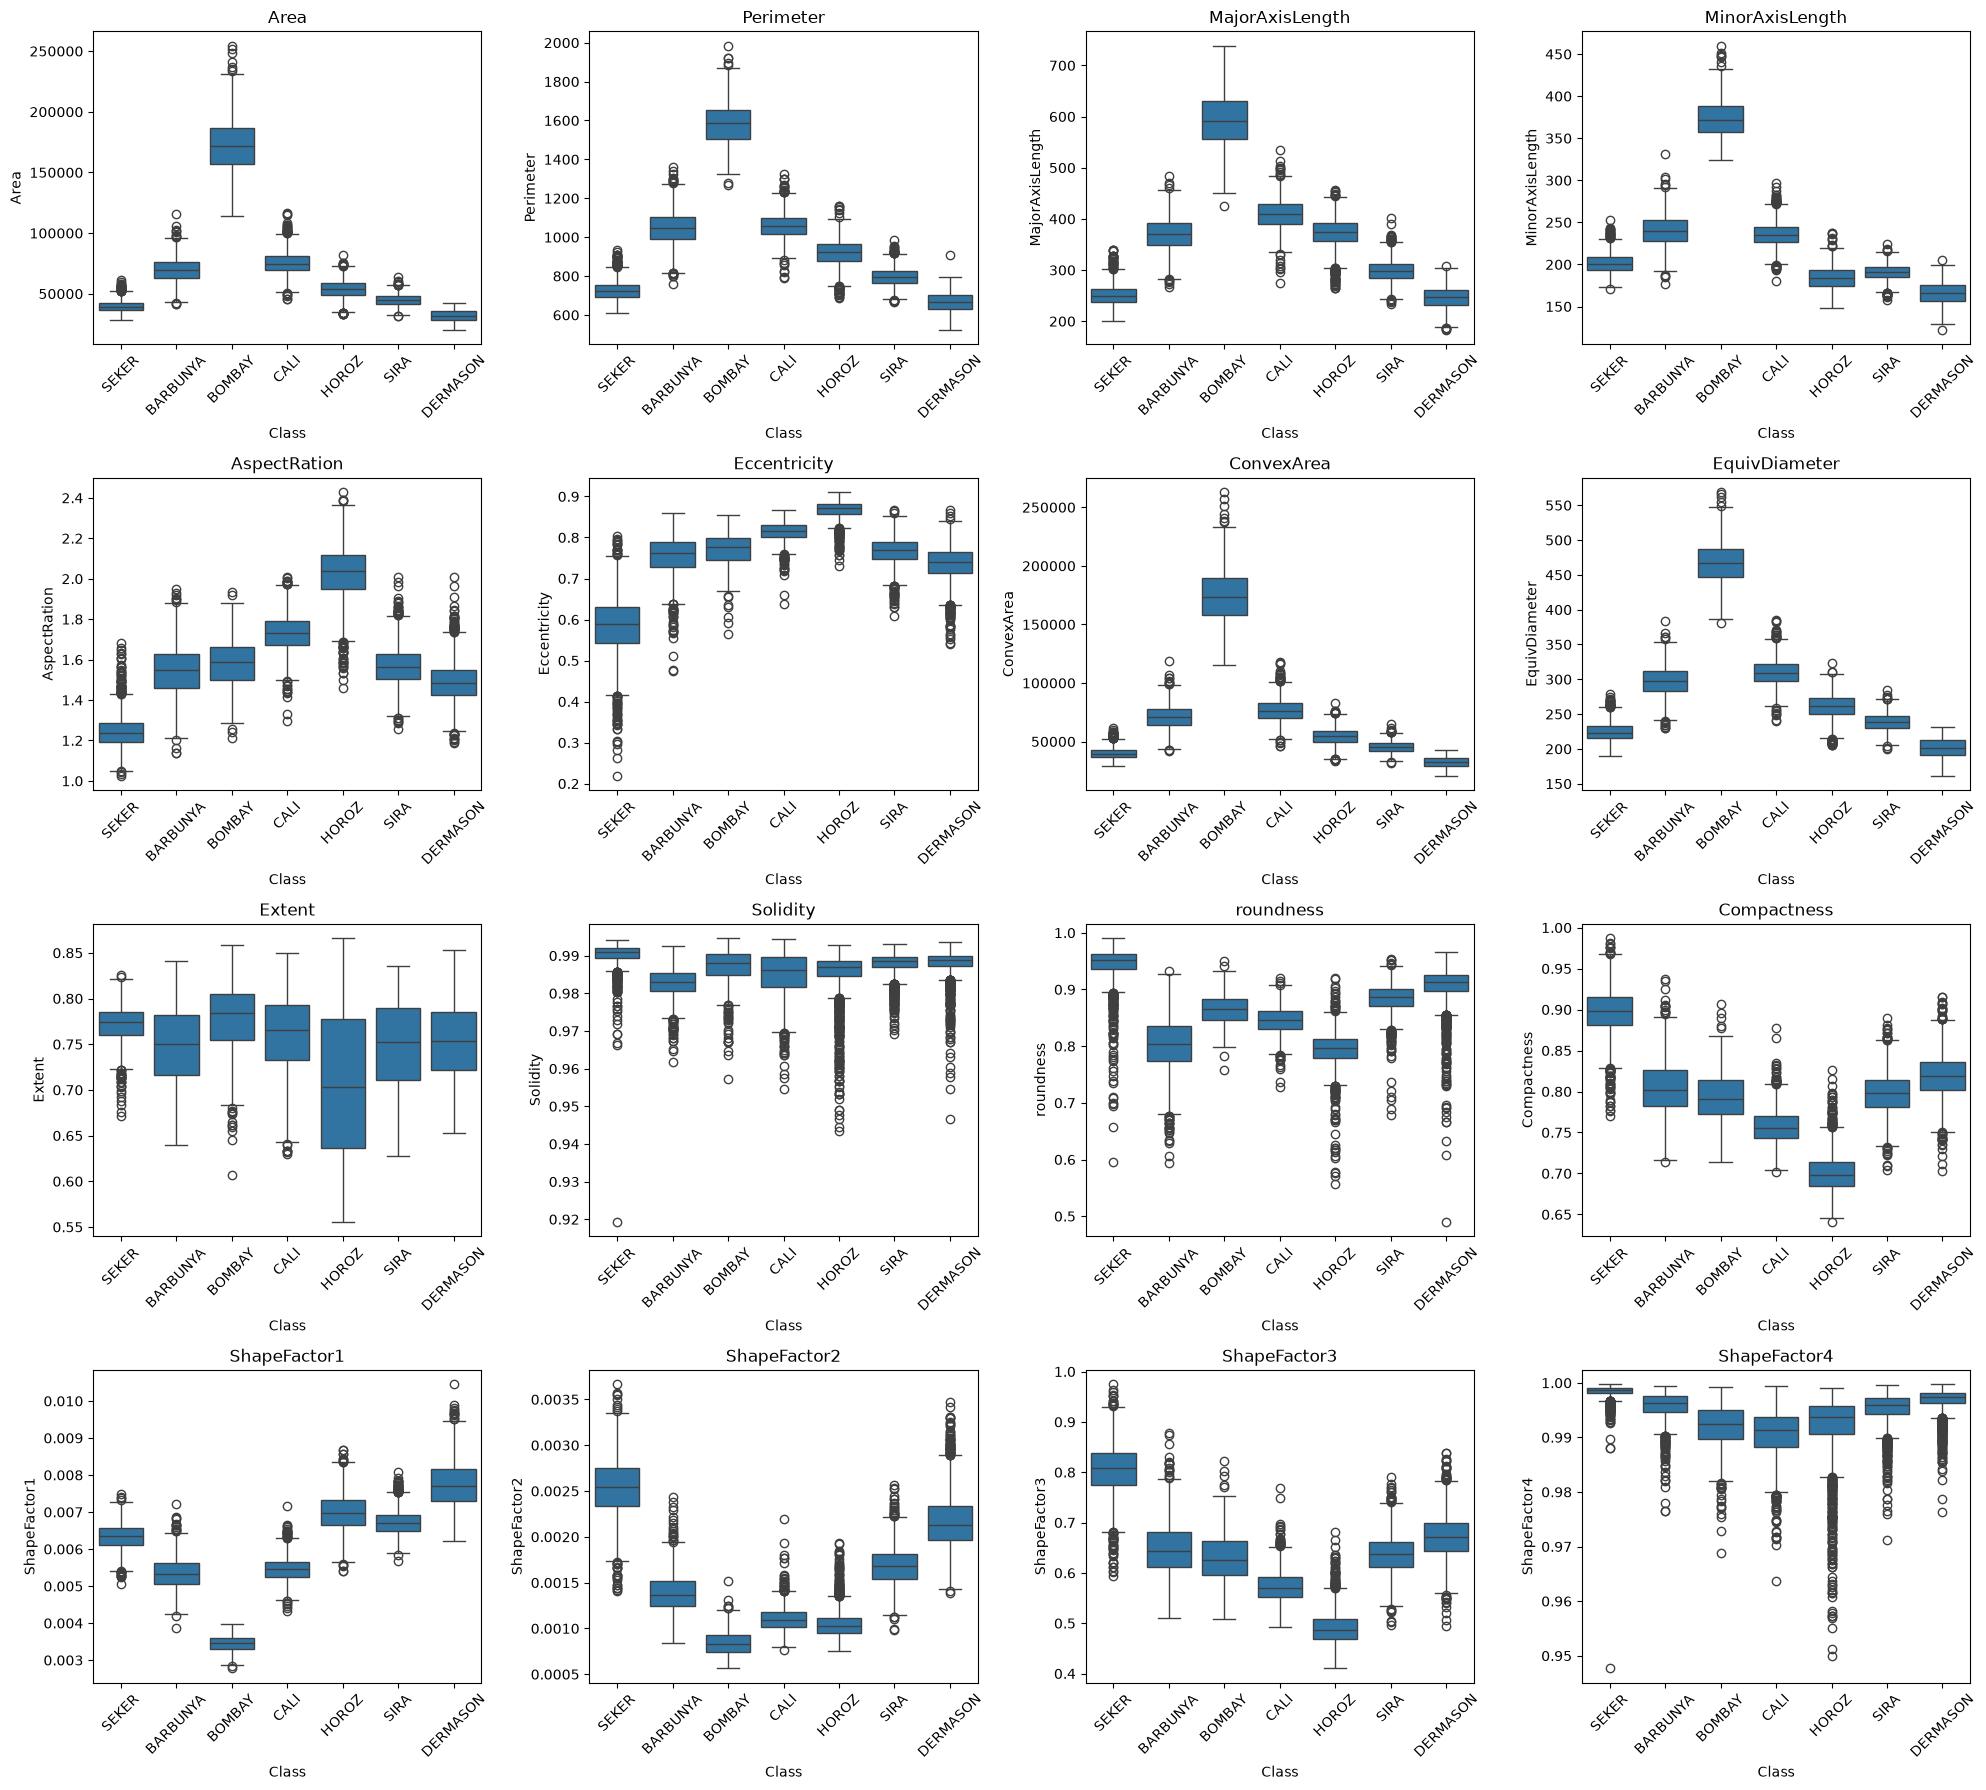

In [24]:
fig, axes = plt.subplots(4, 4, figsize=(20,18))

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='Class', y=col, ax=axes[i//4, i%4])
    axes[i//4, i%4].tick_params(axis='x', rotation=45)
    axes[i//4, i%4].set_title(col)

plt.tight_layout()
plt.show()

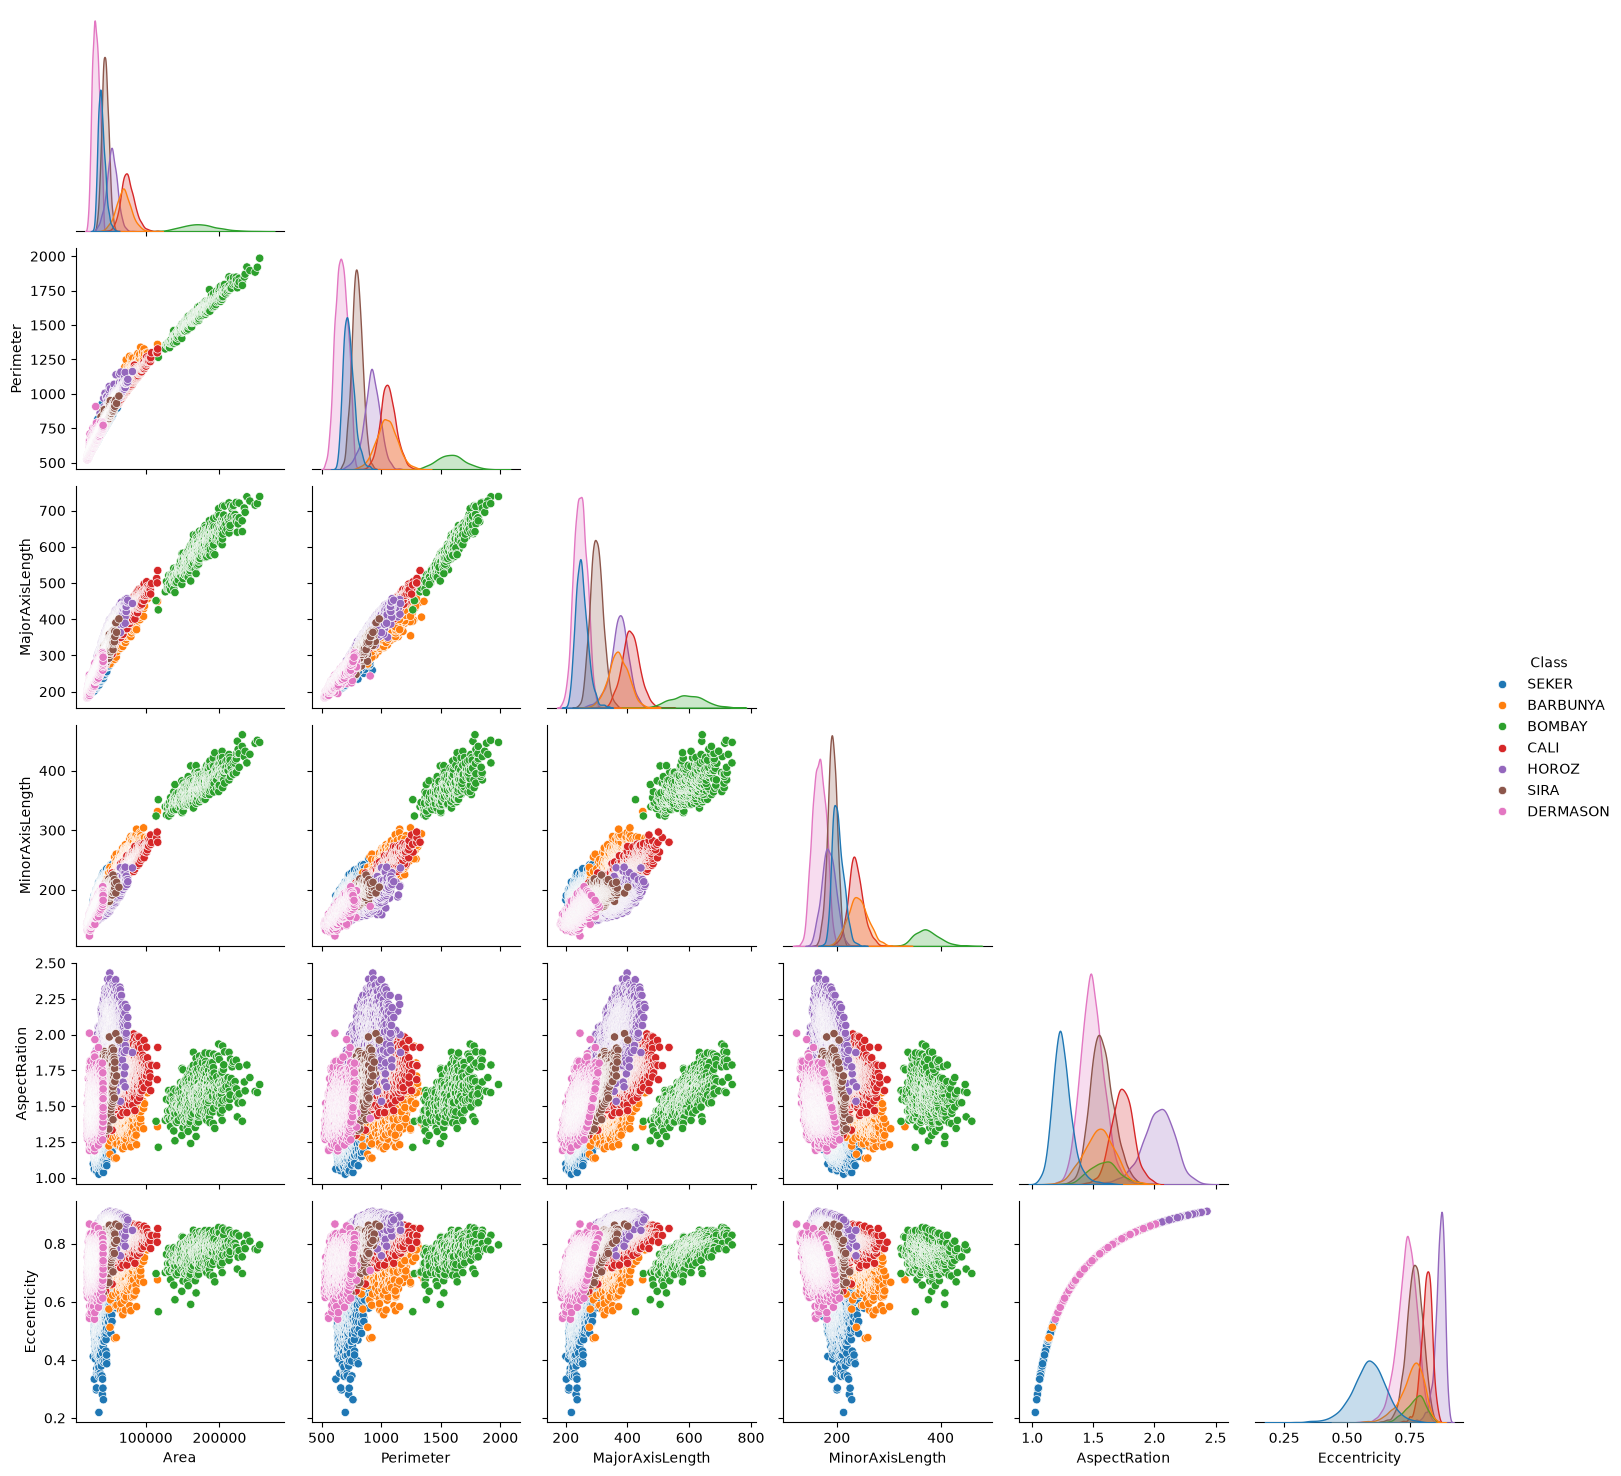

In [25]:
selected_features = [
    'Area',
    'Perimeter',
    'MajorAxisLength',
    'MinorAxisLength',
    'AspectRation',
    'Eccentricity'
]

sns.pairplot(
    df[selected_features + ['Class']],
    hue='Class',
    diag_kind='kde',
    corner=True
)

plt.show()

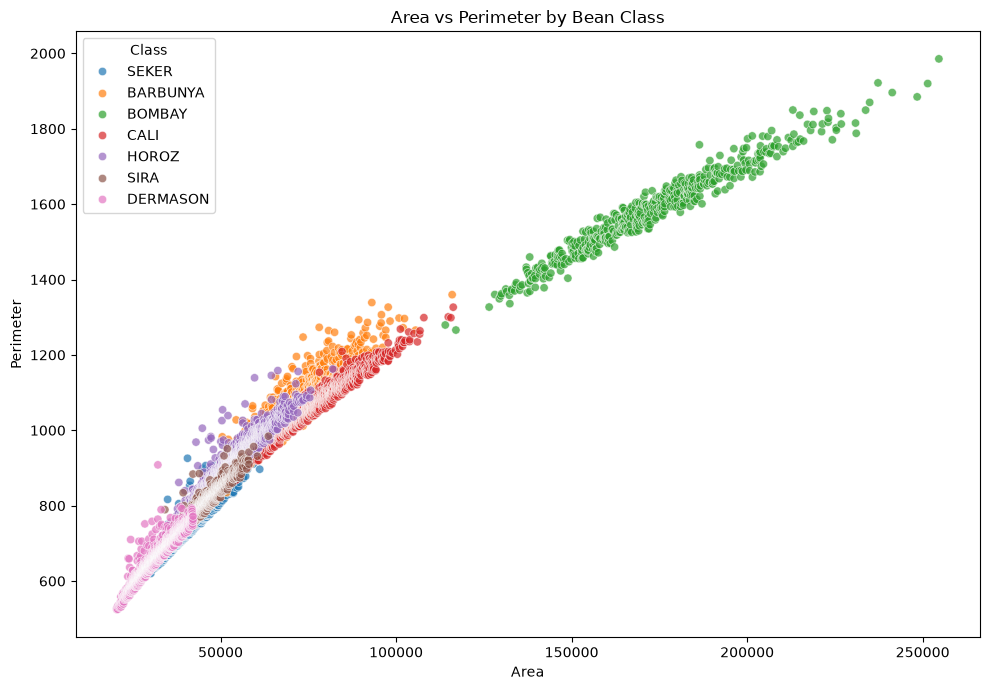

In [26]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df,
    x='Area',
    y='Perimeter',
    hue='Class',
    alpha=0.7
)
plt.title('Area vs Perimeter by Bean Class')
plt.tight_layout()
plt.show()

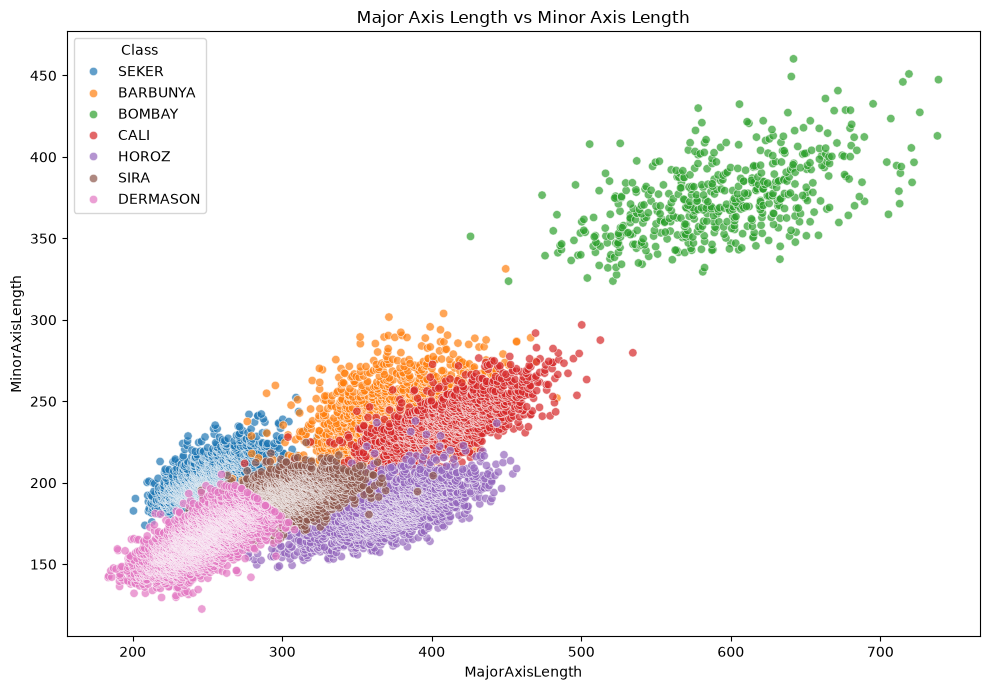

In [27]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df,
    x='MajorAxisLength',
    y='MinorAxisLength',
    hue='Class',
    alpha=0.7
)
plt.title('Major Axis Length vs Minor Axis Length')
plt.tight_layout()
plt.show()

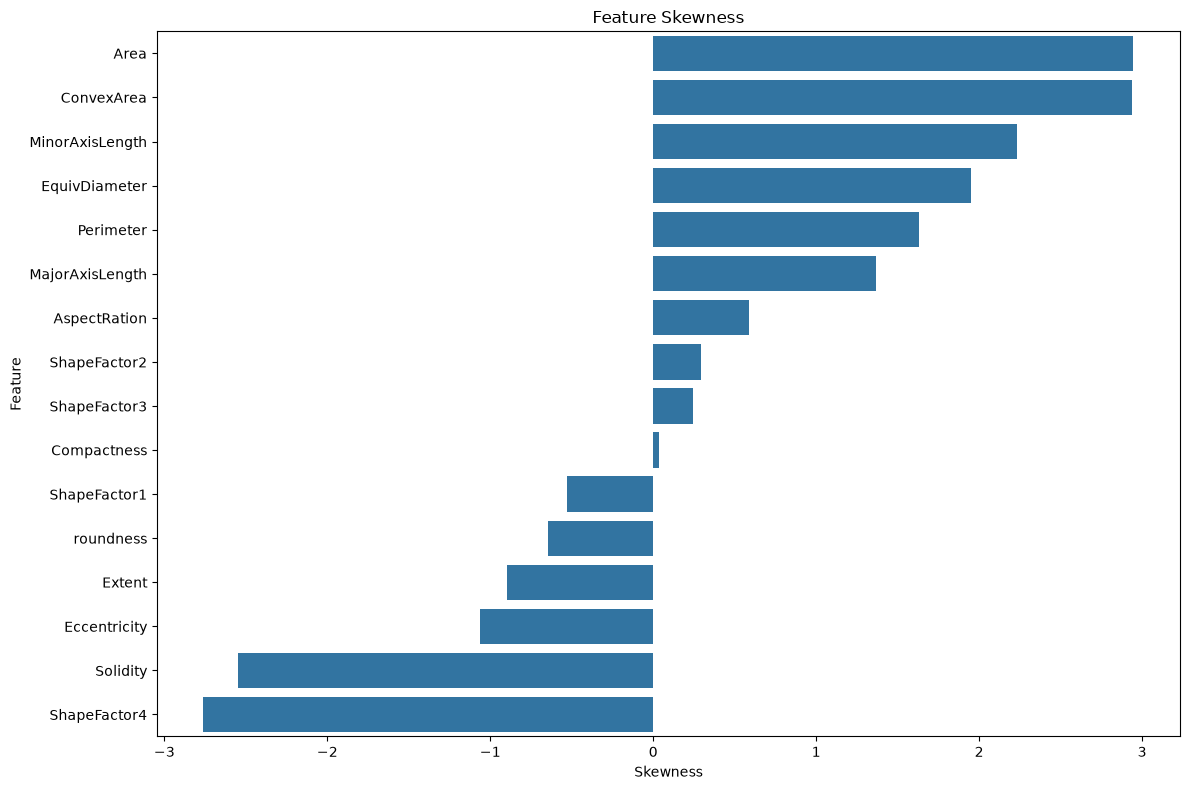

In [28]:
skewness = df[numerical_cols].skew().sort_values(ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(
    x=skewness.values,
    y=skewness.index
)
plt.title('Feature Skewness')
plt.xlabel('Skewness')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [29]:
numerical_cols = df.select_dtypes(include=np.number).columns

Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (df[numerical_cols] < lower_bound) |
    (df[numerical_cols] > upper_bound)
)

outlier_counts = outlier_mask.sum().sort_values(ascending=False)

print(outlier_counts)

Eccentricity       833
Solidity           774
ShapeFactor4       760
MinorAxisLength    567
Area               551
ConvexArea         549
ShapeFactor1       533
EquivDiameter      526
Perimeter          500
AspectRation       485
MajorAxisLength    379
Extent             271
ShapeFactor3       202
Compactness        124
roundness           98
ShapeFactor2         0
dtype: int64


In [30]:
row_outlier_mask = (
    (df[numerical_cols] < lower_bound) |
    (df[numerical_cols] > upper_bound)
).any(axis=1)

df_clean = df.loc[~row_outlier_mask].copy()

print('Original shape:', df.shape)
print('Cleaned shape:', df_clean.shape)
print('Rows removed:', df.shape[0] - df_clean.shape[0])

Original shape: (13543, 17)
Cleaned shape: (10539, 17)
Rows removed: 3004


In [31]:
Q1_clean = df_clean[numerical_cols].quantile(0.25)
Q3_clean = df_clean[numerical_cols].quantile(0.75)
IQR_clean = Q3_clean - Q1_clean

lower_clean = Q1_clean - 1.5 * IQR_clean
upper_clean = Q3_clean + 1.5 * IQR_clean

remaining_outliers = (
    (df_clean[numerical_cols] < lower_clean) |
    (df_clean[numerical_cols] > upper_clean)
).sum()

print(remaining_outliers.sort_values(ascending=False))

AspectRation       448
Eccentricity       362
ShapeFactor4       308
Solidity           251
MinorAxisLength    221
ConvexArea         207
Area               203
roundness           82
EquivDiameter       29
Extent              15
ShapeFactor1         5
Perimeter            1
MajorAxisLength      0
Compactness          0
ShapeFactor2         0
ShapeFactor3         0
dtype: int64


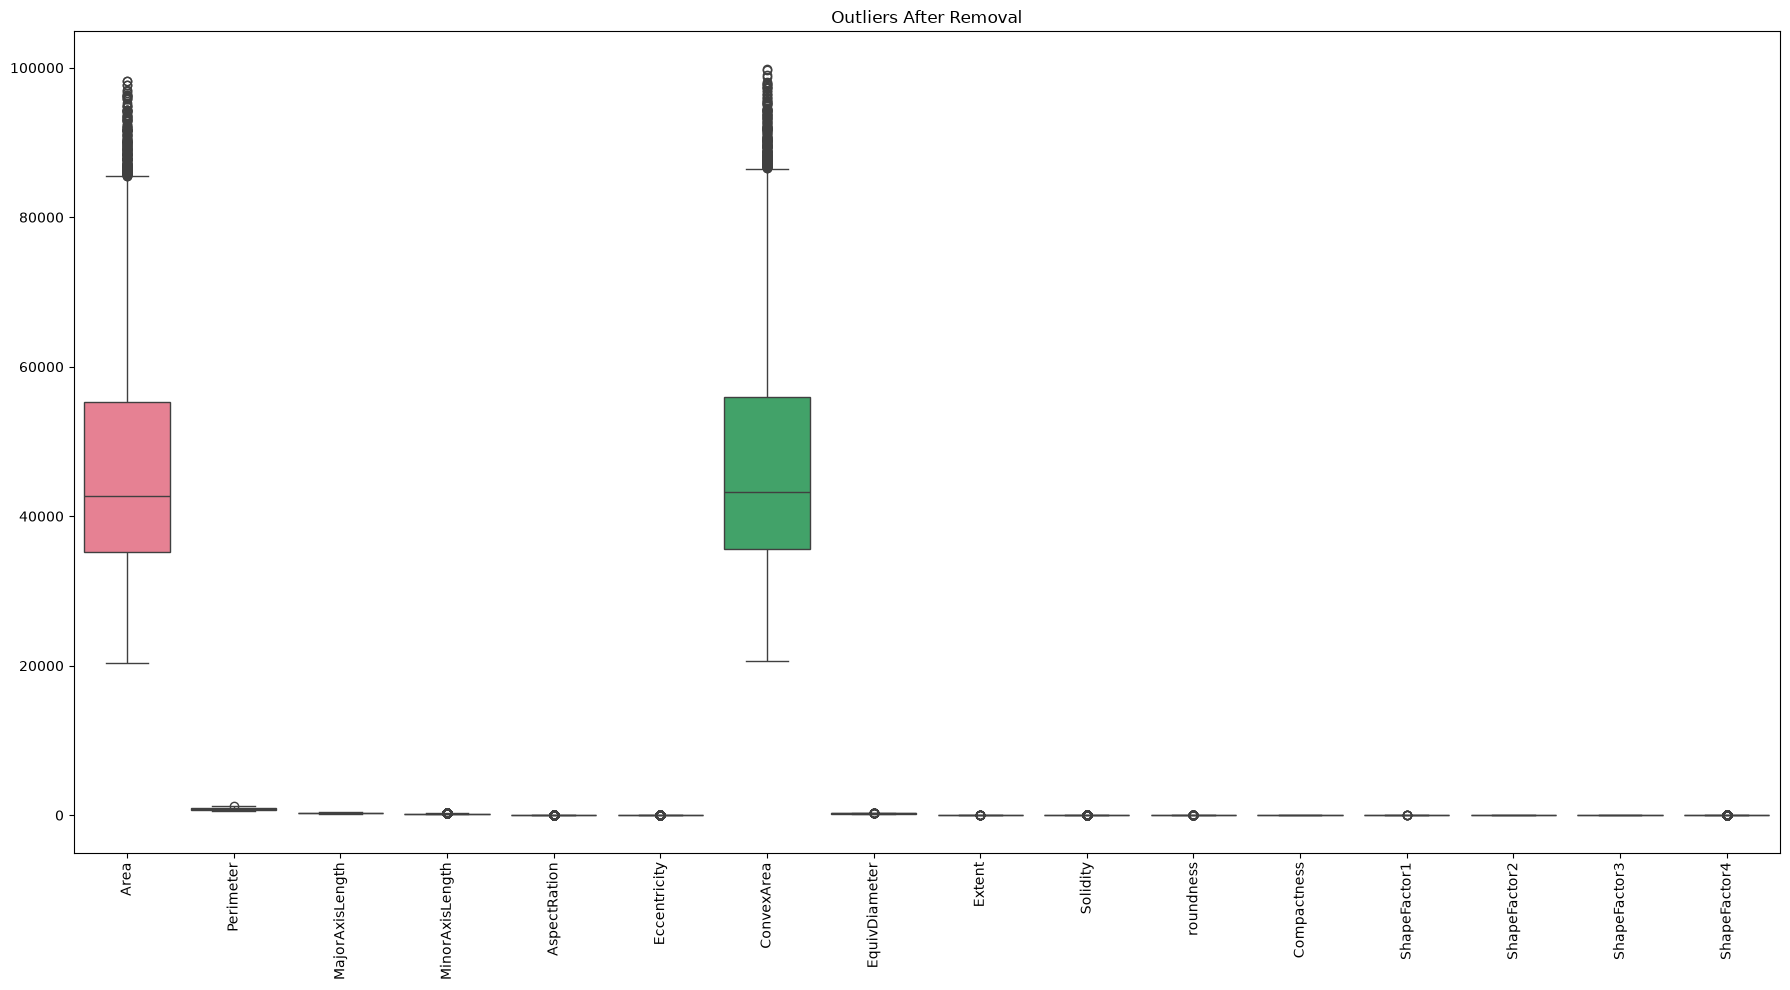

In [32]:
plt.figure(figsize=(18, 10))
sns.boxplot(data=df_clean[numerical_cols])
plt.title('Outliers After Removal')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Class
DERMASON    3463
SIRA        2582
CALI        1222
SEKER       1197
BARBUNYA    1066
HOROZ       1009
Name: count, dtype: int64


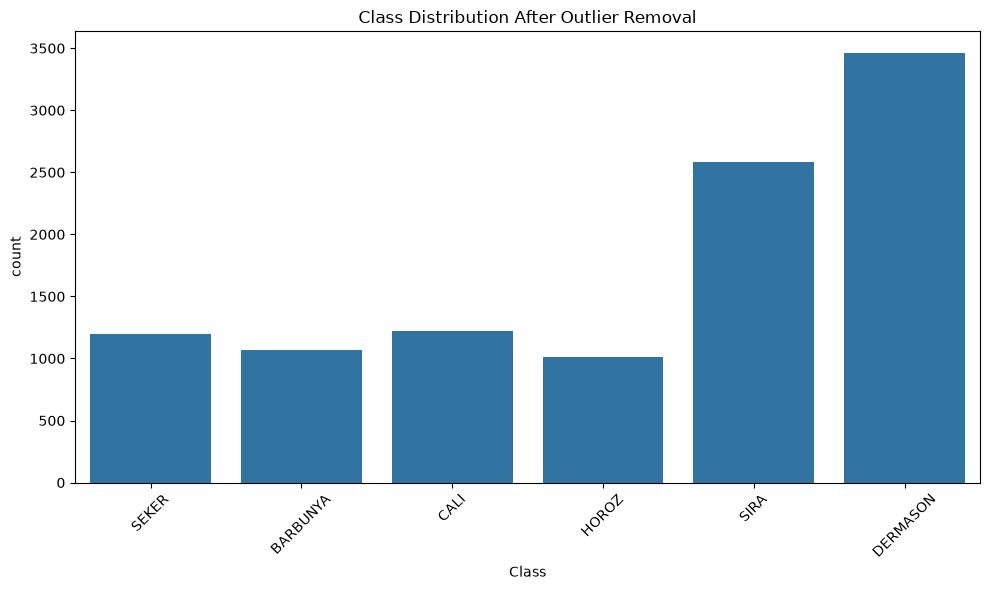

In [33]:
print(df_clean['Class'].value_counts())

plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='Class')
plt.title('Class Distribution After Outlier Removal')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
df = df_clean.copy()

In [35]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

le = LabelEncoder()

df_corr = df.copy()
df_corr['Class_encoded'] = le.fit_transform(df_corr['Class'])

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

feature_target_corr = (
    df_corr[numerical_cols]
    .corrwith(df_corr['Class_encoded'])
    .abs()
    .sort_values(ascending=False)
)

print(feature_target_corr)

ConvexArea         0.384549
Area               0.382175
Perimeter          0.360570
roundness          0.337744
EquivDiameter      0.334168
Solidity           0.320627
MinorAxisLength    0.315794
MajorAxisLength    0.313793
ShapeFactor1       0.208950
ShapeFactor2       0.193974
Eccentricity       0.144559
ShapeFactor3       0.130516
Compactness        0.125944
AspectRation       0.109988
ShapeFactor4       0.109266
Extent             0.025385
dtype: float64


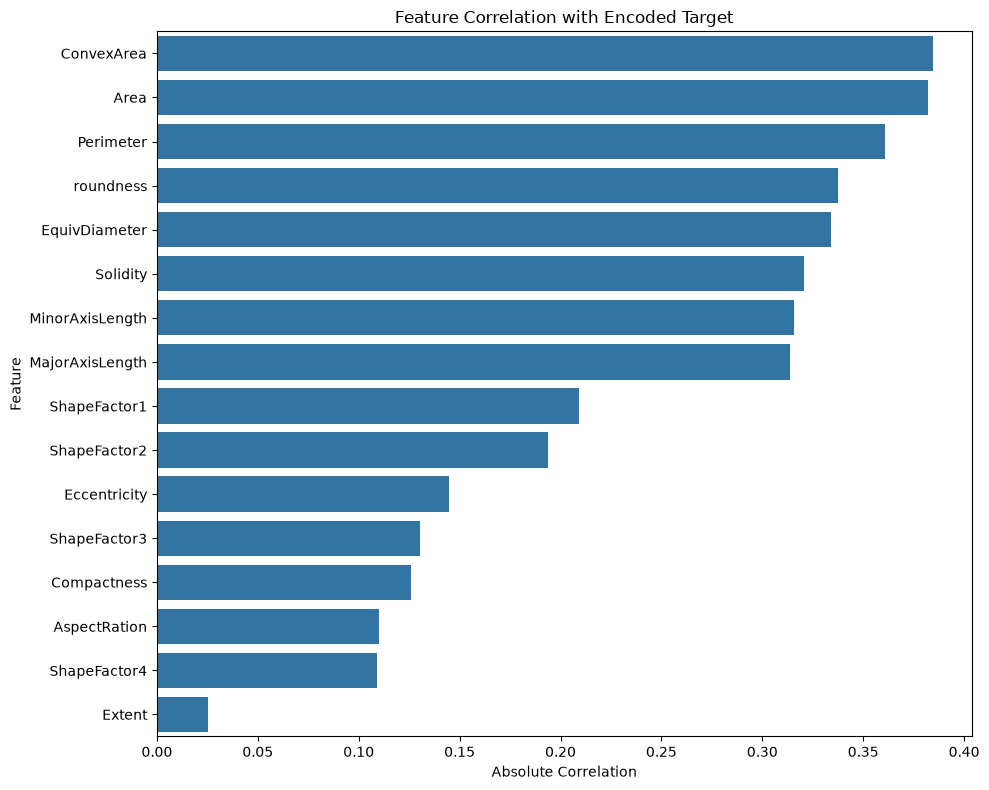

In [36]:
plt.figure(figsize=(10,8))

sns.barplot(
    x=feature_target_corr.values,
    y=feature_target_corr.index
)

plt.title('Feature Correlation with Encoded Target')
plt.xlabel('Absolute Correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [37]:
corr_matrix = df[numerical_cols].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']

high_corr_pairs = high_corr_pairs[
    high_corr_pairs['Correlation'] >= 0.90
].sort_values('Correlation', ascending=False)

print(high_corr_pairs)

           Feature_1        Feature_2  Correlation
6               Area       ConvexArea     0.999953
190      Compactness     ShapeFactor3     0.999161
7               Area    EquivDiameter     0.996258
103       ConvexArea    EquivDiameter     0.996111
23         Perimeter    EquivDiameter     0.992186
75      AspectRation      Compactness     0.992134
94      Eccentricity     ShapeFactor3     0.990037
22         Perimeter       ConvexArea     0.989485
1               Area        Perimeter     0.988951
78      AspectRation     ShapeFactor3     0.986268
60   MinorAxisLength     ShapeFactor1     0.984415
91      Eccentricity      Compactness     0.983575
18         Perimeter  MajorAxisLength     0.973127
39   MajorAxisLength    EquivDiameter     0.960413
2               Area  MajorAxisLength     0.956141
38   MajorAxisLength       ConvexArea     0.956057
69      AspectRation     Eccentricity     0.954604
45   MajorAxisLength     ShapeFactor2     0.929850
55   MinorAxisLength    EquivDi

In [38]:
from sklearn.feature_selection import f_classif

X = df[numerical_cols]
y = df['Class']

f_scores, p_values = f_classif(X, y)

feature_scores = pd.DataFrame({
    'Feature': numerical_cols,
    'F_Score': f_scores,
    'P_Value': p_values
}).sort_values('F_Score', ascending=False)

print(feature_scores)

            Feature       F_Score        P_Value
1         Perimeter  13517.027914   0.000000e+00
2   MajorAxisLength  12557.119349   0.000000e+00
6        ConvexArea  12389.693556   0.000000e+00
0              Area  12269.805567   0.000000e+00
7     EquivDiameter  12231.601436   0.000000e+00
3   MinorAxisLength   9312.215455   0.000000e+00
13     ShapeFactor2   8212.807522   0.000000e+00
12     ShapeFactor1   7595.131767   0.000000e+00
4      AspectRation   6884.952472   0.000000e+00
11      Compactness   6392.371321   0.000000e+00
14     ShapeFactor3   6211.824212   0.000000e+00
10        roundness   6037.331370   0.000000e+00
5      Eccentricity   5656.521317   0.000000e+00
15     ShapeFactor4   1508.860956   0.000000e+00
9          Solidity    888.401310   0.000000e+00
8            Extent    155.702778  4.175437e-160


In [39]:
selected_features = feature_scores[
    feature_scores['P_Value'] < 0.05
]['Feature'].tolist()

selected_corr = df[selected_features].corr().abs()

upper = selected_corr.where(
    np.triu(np.ones(selected_corr.shape), k=1).astype(bool)
)

to_remove = [
    column
    for column in upper.columns
    if any(upper[column] > 0.90)
]

final_features = [
    feature for feature in selected_features
    if feature not in to_remove
]

print('Selected features:')
print(selected_features)

print('\nRemoved redundant features:')
print(to_remove)

print('\nFinal features:')
print(final_features)

Selected features:
['Perimeter', 'MajorAxisLength', 'ConvexArea', 'Area', 'EquivDiameter', 'MinorAxisLength', 'ShapeFactor2', 'ShapeFactor1', 'AspectRation', 'Compactness', 'ShapeFactor3', 'roundness', 'Eccentricity', 'ShapeFactor4', 'Solidity', 'Extent']

Removed redundant features:
['MajorAxisLength', 'ConvexArea', 'Area', 'EquivDiameter', 'MinorAxisLength', 'ShapeFactor2', 'ShapeFactor1', 'Compactness', 'ShapeFactor3', 'Eccentricity']

Final features:
['Perimeter', 'AspectRation', 'roundness', 'ShapeFactor4', 'Solidity', 'Extent']


In [40]:
print('Number of original features:', len(numerical_cols))
print('Number of selected features:', len(selected_features))
print('Number of final features:', len(final_features))

print('\nFinal feature list:')
for feature in final_features:
    print(feature)

Number of original features: 16
Number of selected features: 16
Number of final features: 6

Final feature list:
Perimeter
AspectRation
roundness
ShapeFactor4
Solidity
Extent


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

features = [
    'Perimeter',
    'AspectRation',
    'roundness',
    'ShapeFactor4',
    'Solidity',
    'Extent'
]

X = df[features]
y = df['Class']

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Original training data:", X_train.shape)
print("After SMOTE:", X_train_smote.shape)

k_values = range(1, 21)

accuracy = []
precision = []
recall = []
f1 = []

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test_scaled)

    accuracy.append(accuracy_score(y_test, y_pred))
    precision.append(precision_score(y_test, y_pred, average='weighted'))
    recall.append(recall_score(y_test, y_pred, average='weighted'))
    f1.append(f1_score(y_test, y_pred, average='weighted'))

best_k = k_values[np.argmax(f1)]

print("Best K:", best_k)

model = KNeighborsClassifier(n_neighbors=best_k)

model.fit(X_train_smote, y_train_smote)

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1_score_value = f1_score(y_test, y_pred, average='weighted')

print("\nFinal Results")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1_score_value)

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

Original training data: (8431, 6)
After SMOTE: (16620, 6)
Best K: 11

Final Results
Accuracy : 0.900853889943074
Precision: 0.9022112916655046
Recall   : 0.900853889943074
F1 Score : 0.9009840910493274

Classification Report
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.90      0.92       213
        CALI       0.92      0.93      0.92       244
    DERMASON       0.93      0.88      0.90       693
       HOROZ       0.90      0.94      0.92       202
       SEKER       0.87      0.93      0.90       239
        SIRA       0.86      0.89      0.88       517

    accuracy                           0.90      2108
   macro avg       0.90      0.91      0.91      2108
weighted avg       0.90      0.90      0.90      2108



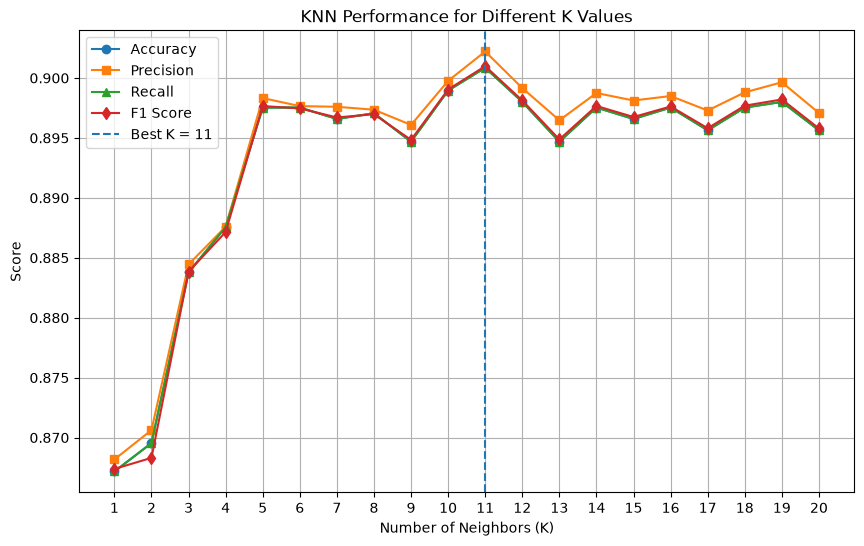

In [42]:
plt.figure(figsize=(10,6))

plt.plot(k_values, accuracy, marker='o', label='Accuracy')
plt.plot(k_values, precision, marker='s', label='Precision')
plt.plot(k_values, recall, marker='^', label='Recall')
plt.plot(k_values, f1, marker='d', label='F1 Score')

plt.axvline(best_k, linestyle='--', label=f'Best K = {best_k}')

plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Score')
plt.title('KNN Performance for Different K Values')
plt.xticks(k_values)
plt.legend()
plt.grid()
plt.show()

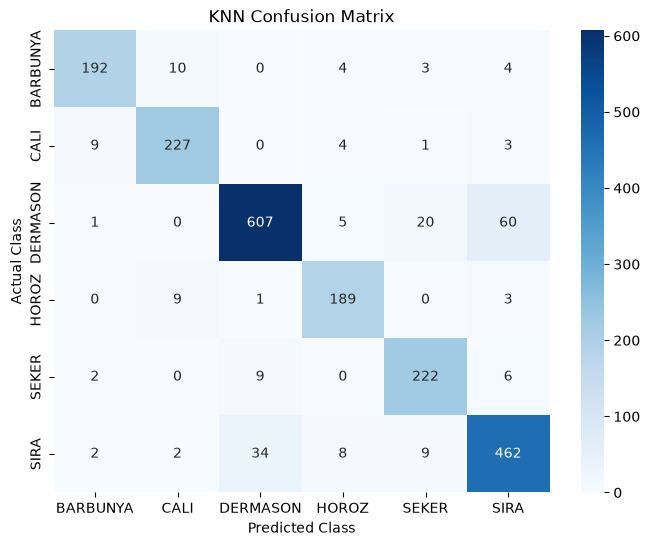

In [43]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('KNN Confusion Matrix')

plt.show()

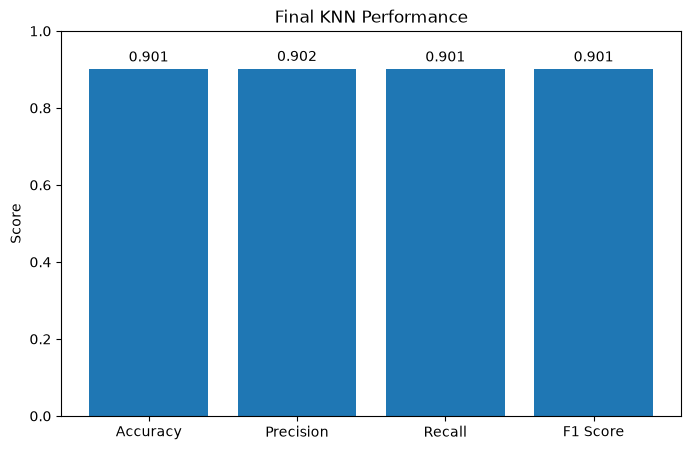

In [44]:
metrics = {
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1 Score': f1_score_value
}

plt.figure(figsize=(8,5))

plt.bar(metrics.keys(), metrics.values())

plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Final KNN Performance')

for i, value in enumerate(metrics.values()):
    plt.text(i, value + 0.02, f'{value:.3f}', ha='center')

plt.show()

In [45]:
import joblib

model_package = {
    'model': model,
    'scaler': scaler,
    'label_encoder': le,
    'features': features,
    'best_k': best_k
}

joblib.dump(model_package, 'knn_dry_bean_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [46]:
new_data = pd.DataFrame([{
    'Perimeter': 650,
    'AspectRation': 1.85,
    'roundness': 0.72,
    'ShapeFactor4': 0.99,
    'Solidity': 0.98,
    'Extent': 0.75
}])

new_scaled = scaler.transform(new_data[features])

prediction = model.predict(new_scaled)

predicted_class = le.inverse_transform(prediction)

print("Predicted Class:", predicted_class[0])

Predicted Class: HOROZ


In [47]:
features = [
    'Perimeter',
    'AspectRation',
    'roundness',
    'ShapeFactor4',
    'Solidity',
    'Extent'
]

df_final = df[features + ['Class']].copy()

df_final.to_csv(
    'dry_bean_selected_features.csv',
    index=False
)

print("File saved successfully!")
print(df_final.shape)
print(df_final.head())

File saved successfully!
(10539, 7)
    Perimeter  AspectRation  roundness  ShapeFactor4  Solidity    Extent  \
23    656.711      1.308864   0.921842      0.999091  0.987268  0.761823   
24    657.431      1.382816   0.920929      0.994950  0.989565  0.740936   
29    642.092      1.238051   0.969600      0.999515  0.992481  0.773877   
31    662.532      1.225284   0.911040      0.999481  0.986026  0.774848   
32    656.404      1.246471   0.928538      0.998843  0.987561  0.785246   

    Class  
23  SEKER  
24  SEKER  
29  SEKER  
31  SEKER  
32  SEKER  
